In [ ]:
# 1. Найдите час суток с максимальным числом поездок в выходные дни
import pandas as pd

# Загружаем данные
df = pd.read_csv("5 train.csv")
df["datetime"] = pd.to_datetime(df["datetime"])

# ============= ЗАДАЧА 1: Час суток с максимальным числом поездок в выходные дни =============

# Фильтруем выходные дни
weekend = df[df["workingday"] == 0]

# Группируем по часам
hourly = weekend.groupby(weekend["datetime"].dt.hour)["count"].mean()

# Находим максимальный час
max_hour = hourly.idxmax()
max_value = hourly.max()

print(f"Час с максимальным числом поездок в выходные: {max_hour}:00")
print(f"Среднее число поездок: {max_value:.0f}")

Час с максимальным числом поездок в выходные: 13:00
Среднее число поездок: 388


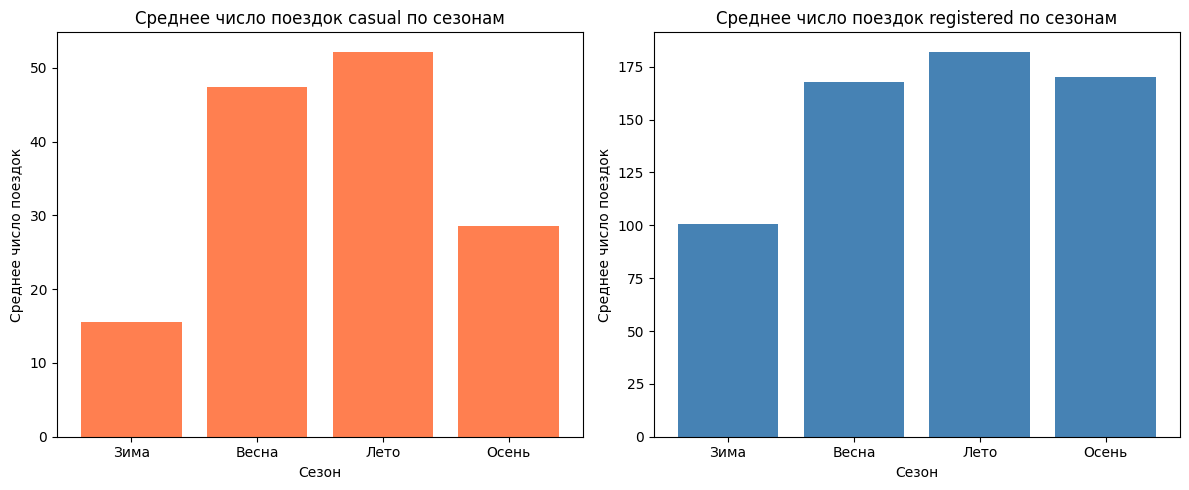

In [ ]:
#  2. Постройте столбчатую диаграмму: среднее число поездок (casual и registered отдельно) по сезонам
import pandas as pd
import matplotlib.pyplot as plt

# загрузка данных
df = pd.read_csv("5 train.csv")

# ============= ЗАДАЧА 2: Столбчатая диаграмма (casual и registered по сезонам) =============

# группируем данные по сезонам и считаем среднее арифметическое для двух столбцов
season_stats = df.groupby("season").agg({
    "casual": "mean",
    "registered": "mean"
})

season_stats.index = ["Зима", "Весна", "Лето", "Осень"]

# создаем 2 графика рядом
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# диаграмма casual
ax1.bar(season_stats.index, season_stats["casual"], color="coral")
ax1.set_title("Среднее число поездок casual по сезонам")
ax1.set_xlabel("Сезон")
ax1.set_ylabel("Среднее число поездок")

# диаграмма registered
ax2.bar(season_stats.index, season_stats["registered"], color="steelblue")
ax2.set_title("Среднее число поездок registered по сезонам")
ax2.set_xlabel("Сезон")
ax2.set_ylabel("Среднее число поездок")

plt.tight_layout()
plt.show()

In [4]:
# 3. Фильтр: найдите все наблюдения, где count > 500 — сколько их? В какое время года чаще всего?

import pandas as pd

# загрузка данных
df = pd.read_csv("5 train.csv")

# ============= ЗАДАЧА 3: Фильтр: наблюдения, где count > 500 =============

big_rides = df[df["count"] > 500]

print("Количество наблюдений:", len(big_rides))

season_counts = big_rides["season"].value_counts()

season_names = {
    1: "Зима",
    2: "Весна",
    3: "Лето",
    4: "Осень"
}

season_counts.index = season_counts.index.map(season_names)

# Находим сезон с максимумом
max_season = season_counts.idxmax()
max_count = season_counts.max()

print(f"Чаще всего count > 500 бывает: {max_season} ({max_count} наблюдений)")

Количество наблюдений: 797
Чаще всего count > 500 бывает: Весна (281 наблюдений)


In [5]:
import pandas as pd

# загрузка данных
df = pd.read_csv("5 train.csv")

# ============= ЗАДАЧА 4: Средняя температура и среднее число поездок по каждому месяцу.  Сохранение в CSV таблицу =============

df["datetime"] = pd.to_datetime(df["datetime"])

monthly_stats = df.groupby(df["datetime"].dt.month).agg({
    "temp": "mean",
    "count": "mean"
}).round(1)

# Переименовываем месяцы
month_names = {
    1: "Январь",
    2: "Февраль",
    3: "Март",
    4: "Апрель",
    5: "Май",
    6: "Июнь",
    7: "Июль",
    8: "Август",
    9: "Сентябрь",
    10: "Октябрь",
    11: "Ноябрь",
    12: "Декабрь"
}

monthly_stats.index = [month_names[i] for i in monthly_stats.index]
monthly_stats.columns = ["Средняя температура", "Среднее число поездок"]

# Заменяем точку на запятую для чисел
monthly_stats = monthly_stats.astype(str)
for col in monthly_stats.columns:
    monthly_stats[col] = monthly_stats[col].str.replace('.', ',')

# Сохраняем в CSV
monthly_stats.to_csv("monthly_stats.csv", sep=";", encoding="utf-8-sig")

print("Файл сохранён: monthly_stats.csv")
print(monthly_stats)

Файл сохранён: monthly_stats.csv
         Средняя температура Среднее число поездок
Январь                   9,8                  90,4
Февраль                 11,8                 110,0
Март                    15,9                 148,2
Апрель                  18,7                 184,2
Май                     22,7                 219,5
Июнь                    27,1                 242,0
Июль                    30,8                 235,3
Август                  29,7                 234,1
Сентябрь                25,8                 233,8
Октябрь                 20,9                 227,7
Ноябрь                  15,2                 193,7
Декабрь                 13,8                 175,6
